In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron #used for simple linear classification tasks.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
!pip install tensorflow

In [3]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPooling2D 
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.utils import to_categorical 

In [5]:
df=pd.read_csv(r'C:\Users\Dell\Documents\Models_Training\CNN Projects\Digit Detection/mnist_train.csv')
df_test=pd.read_csv(r'C:\Users\Dell\Documents\Models_Training\CNN Projects\Digit Detection/mnist_test.csv')

In [6]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
df.shape

(60000, 785)

In [8]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [9]:
df.isnull().sum()

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

In [10]:
X_train=df.drop('label',axis=1).values
y_train=df['label'].values
X_test=df_test.drop('label',axis=1).values
y_test=df_test['label'].values

In [11]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

In [12]:
X_train_img=X_train.reshape(-1,28,28)
X_test_img=X_test.reshape(-1,28,28)

In [13]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [14]:
X_train_img

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [15]:
y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

In [16]:
y_train_cat

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [17]:
y_train

array([5, 0, 4, ..., 5, 6, 8])

In [18]:
perceptron=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

In [19]:
perceptron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'
])

In [20]:
histrory_percp=perceptron.fit(X_train_img,y_train_cat,epochs=5,batch_size=32, validation_data=(X_test_img,y_test_cat), verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8122 - loss: 0.7866 - val_accuracy: 0.8825 - val_loss: 0.4807
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8813 - loss: 0.4558 - val_accuracy: 0.8961 - val_loss: 0.4000
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8923 - loss: 0.4030 - val_accuracy: 0.9007 - val_loss: 0.3680
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8976 - loss: 0.3766 - val_accuracy: 0.9049 - val_loss: 0.3483
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9008 - loss: 0.3600 - val_accuracy: 0.9080 - val_loss: 0.3357


In [21]:
acc_percp=perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [22]:
acc_percp

0.9079999923706055

In [23]:
#ANN

In [24]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax'),
    
])

In [25]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'
])

In [26]:
histrory_ann=ann.fit(X_train_img,y_train_cat,epochs=5,batch_size=32, validation_data=(X_test_img,y_test_cat), verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9293 - loss: 0.2394 - val_accuracy: 0.9596 - val_loss: 0.1283
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9685 - loss: 0.1047 - val_accuracy: 0.9704 - val_loss: 0.0949
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9774 - loss: 0.0715 - val_accuracy: 0.9706 - val_loss: 0.0927
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9828 - loss: 0.0551 - val_accuracy: 0.9737 - val_loss: 0.0855
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9862 - loss: 0.0423 - val_accuracy: 0.9747 - val_loss: 0.0850


In [27]:
acc_ann=ann.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [28]:
acc_ann

0.9746999740600586

#CNN

In [29]:
X_train_cnn=X_train.reshape(-1,28,28,1)
X_test_cnn=X_test.reshape(-1,28,28,1)

In [30]:
cnn=Sequential([
    Conv2D(32, kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

In [31]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'
])

In [32]:
histrory_cnn=cnn.fit(X_train_cnn,y_train_cat,epochs=5,batch_size=32, validation_data=(X_test_cnn,y_test_cat), verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 29ms/step - accuracy: 0.9361 - loss: 0.2095 - val_accuracy: 0.9834 - val_loss: 0.0481
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9760 - loss: 0.0826 - val_accuracy: 0.9883 - val_loss: 0.0321
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9825 - loss: 0.0626 - val_accuracy: 0.9901 - val_loss: 0.0286
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9853 - loss: 0.0479 - val_accuracy: 0.9916 - val_loss: 0.0250
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 27ms/step - accuracy: 0.9869 - loss: 0.0417 - val_accuracy: 0.9921 - val_loss: 0.0247


In [33]:
acc_cnn=cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]

In [34]:
acc_cnn

0.9921000003814697

In [35]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'],label='Train')
    plt.plot(history.history['val_accuracy'],label='val')
    plt.title(f"{title} Accuracy")
    plt.legend()
    

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'],label='Train')
    plt.plot(history.history['val_loss'],label='val')
    plt.title(f"{title} loss")
    plt.legend()
    plt.show()

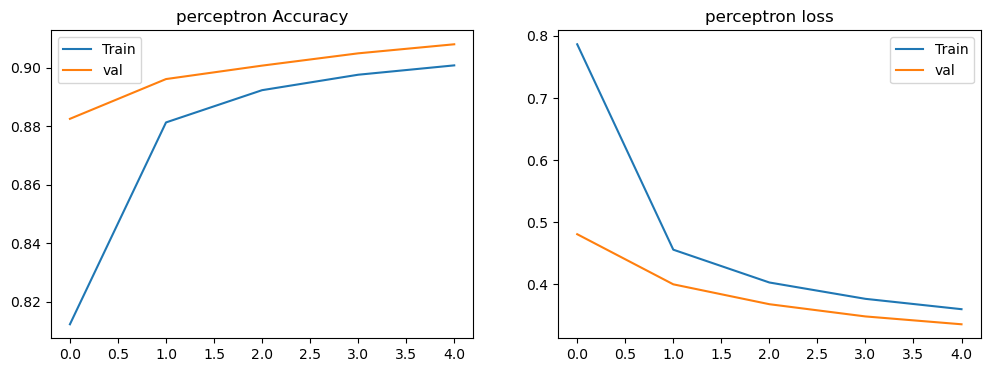

In [36]:
plot_training(histrory_percp, "perceptron")

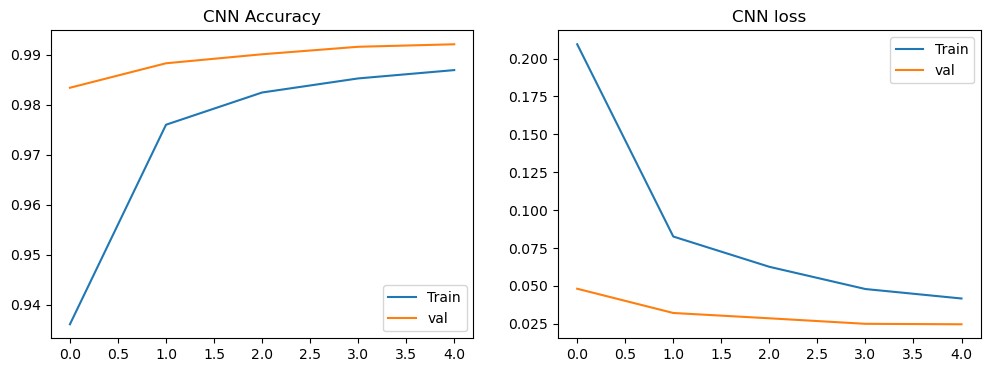

In [37]:
plot_training(histrory_cnn, "CNN")

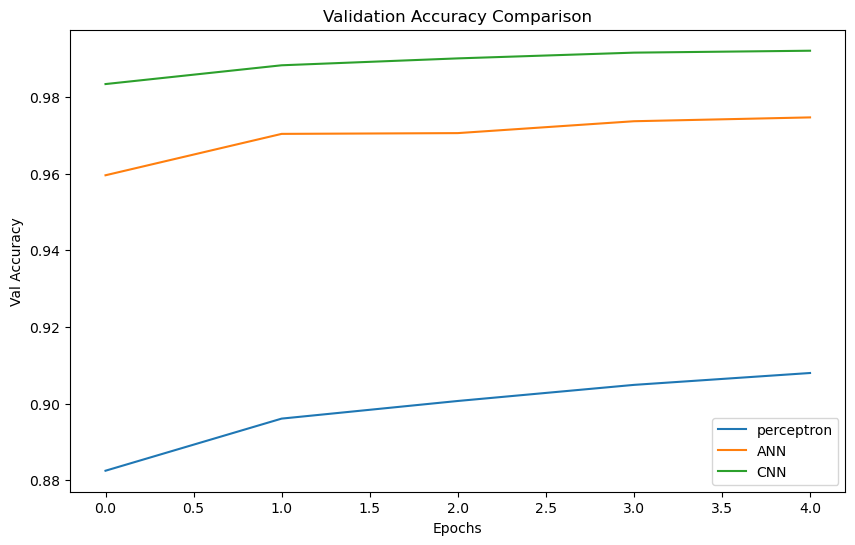

In [38]:
plt.figure(figsize=(10,6))
plt.plot(histrory_percp.history['val_accuracy'], label="perceptron")
plt.plot(histrory_ann.history['val_accuracy'], label="ANN")
plt.plot(histrory_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


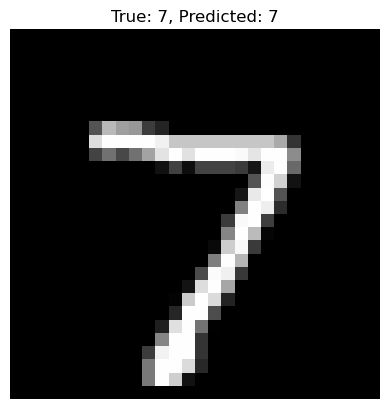

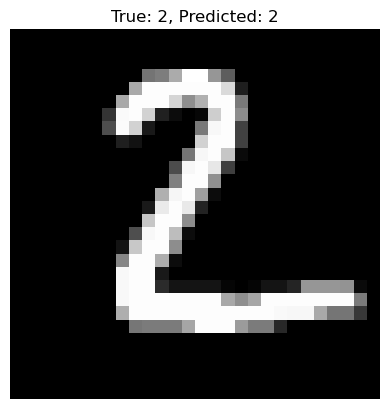

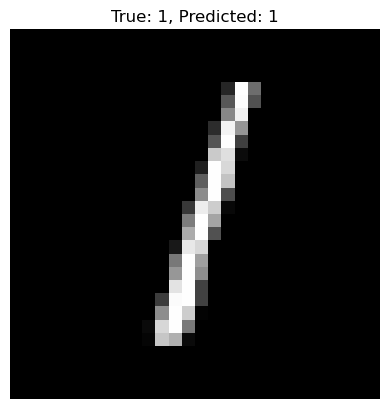

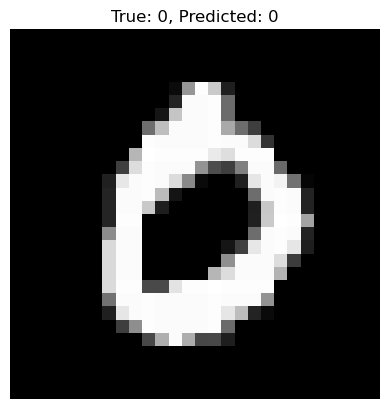

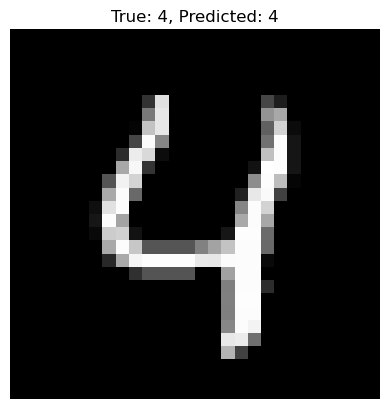

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
X_test = X_test.reshape(-1, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
predictions = cnn.predict(X_test_cnn)
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_cat, axis=1)
for i in range(5):
    plt.imshow(X_test_cnn[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {true_labels[i]}, Predicted: {pred_labels[i]}")
    plt.axis('off')
    plt.show()
